## Ejercicio 1

Entrenando red con 10 neuronas ocultas: 
 --> Única (20%) | Acierto: 95.56%
 --> K=5  | Media: 93.60% | Varianza: 0.7815
 --> K=10 | Media: 92.60% | Varianza: 3.9346

Entrenando red con 50 neuronas ocultas: 
 --> Única (20%) | Acierto: 98.33%
 --> K=5  | Media: 97.61% | Varianza: 0.7034
 --> K=10 | Media: 97.72% | Varianza: 1.7136

Entrenando red con 100 neuronas ocultas: 
 --> Única (20%) | Acierto: 97.78%
 --> K=5  | Media: 97.55% | Varianza: 0.6025
 --> K=10 | Media: 97.77% | Varianza: 0.8743

Entrenando red con 150 neuronas ocultas: 
 --> Única (20%) | Acierto: 97.78%
 --> K=5  | Media: 97.66% | Varianza: 0.2369
 --> K=10 | Media: 97.83% | Varianza: 0.9011



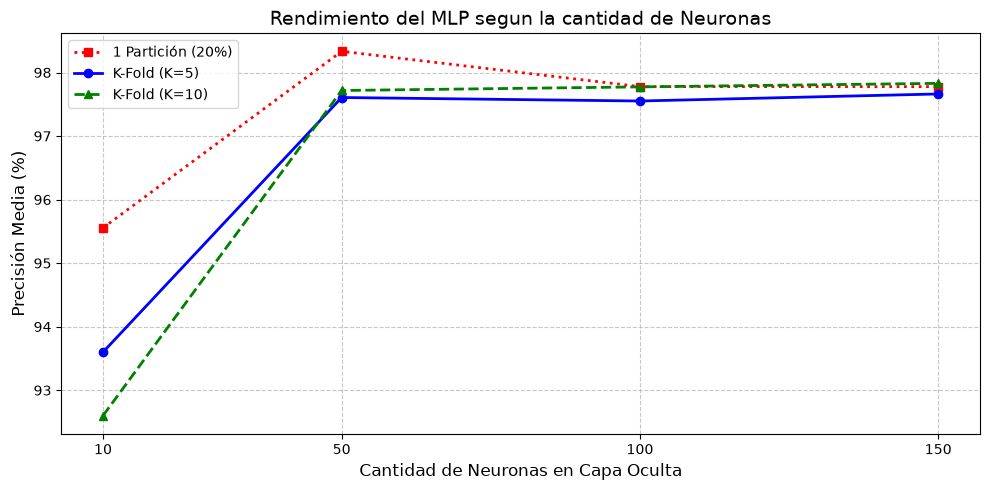

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import KFold
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold, train_test_split

# Datos
digits = load_digits()
X, y = digits.data, digits.target

def evaluar_kfolds(neuronas, k_folds):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    aciertos = []

    for train_idx, test_idx in kf.split(X):
        modelo = MLPClassifier(hidden_layer_sizes=(neuronas,), activation='logistic', learning_rate_init=0.01, max_iter=1000) # Sigmoide
        modelo.fit(X[train_idx], y[train_idx])
        acierto = modelo.score(X[test_idx], y[test_idx])
        aciertos.append(acierto)

    # se puede usar: 
    # scores = cross_val_score(modelo, X, y, cv=kf) --> devuelve los aciertos en una lista

    aciertos = np.array(aciertos) * 100.0
    media = np.mean(aciertos)
    varianza = np.var(aciertos) 
    
    return media, varianza

def evaluar_tts(neuronas):
    # 0.2 --> 20% para probar, 80% para entrenar
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    modelo = MLPClassifier(hidden_layer_sizes=(neuronas,), activation='logistic', learning_rate_init=0.01, max_iter=1000) # Sigmoide
    modelo.fit(X_train, y_train)
    acierto = modelo.score(X_test, y_test)
    return acierto * 100.0



if __name__ == "__main__":
    arquitecturas = [10, 50, 100, 150]

    medias_tts = []
    medias_5 = []; varianzas_5 = []
    medias_10 = []; varianzas_10 = []
    
    for neuronas in arquitecturas:
        print(f"Entrenando red con {neuronas} neuronas ocultas: ")
        
        # TTS 
        acierto_tts = evaluar_tts(neuronas)
        medias_tts.append(acierto_tts)
        print(f" --> Única (20%) | Acierto: {acierto_tts:.2f}%")
        
        # K=5
        media5, varianza5 = evaluar_kfolds(neuronas, k_folds=5)
        medias_5.append(media5)
        varianzas_5.append(varianza5)
        print(f" --> K=5  | Media: {media5:.2f}% | Varianza: {varianza5:.4f}")
        
        # K=10
        media10, varianza10 = evaluar_kfolds(neuronas, k_folds=10)
        medias_10.append(media10)
        varianzas_10.append(varianza10)
        print(f" --> K=10 | Media: {media10:.2f}% | Varianza: {varianza10:.4f}\n")
        


    # --- GRAFICO ---
    plt.figure(figsize=(10, 5))
    plt.plot(arquitecturas, medias_tts, marker='s', color='r', linestyle=':', linewidth=2, label='1 Partición (20%)')
    plt.plot(arquitecturas, medias_5, marker='o', color='b', linestyle='-', linewidth=2, label='K-Fold (K=5)')
    plt.plot(arquitecturas, medias_10, marker='^', color='g', linestyle='--', linewidth=2, label='K-Fold (K=10)')
    
    # Configuraciones visuales
    plt.title("Rendimiento del MLP segun la cantidad de Neuronas", fontsize=14)
    plt.xlabel("Cantidad de Neuronas en Capa Oculta", fontsize=12)
    plt.ylabel("Precisión Media (%)", fontsize=12)
    plt.xticks(arquitecturas)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.tight_layout()
    plt.show()